# 1.Import Library yang dibutuhkan dan Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muqaddasejaz/job-market-and-skills-demand-dataset")

print("Path to dataset files:", path)

100%|██████████| 139k/139k [00:00<00:00, 41.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/muqaddasejaz/job-market-and-skills-demand-dataset/versions/1


In [ ]:
df = pd.read_csv(os.path.join(path, "future_jobs_dataset.csv"))
df.head(5)

,job_id,job_title,industry,location,salary_usd,skills_required,remote_option,company_size,posting_date
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,"Linear Algebra, Quantum Algorithms",No,Large,2025-07-22
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,"Climate Data Analysis, Energy Modeling",Yes,Large,2025-09-26
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,"Linear Algebra, Qiskit",No,Medium,2025-12-31
3,4,Sustainability Analyst,Green Tech,Singapore,113822,"Climate Data Analysis, Energy Modeling",No,Large,2025-05-29
4,5,Smart Contract Engineer,Blockchain,London,92575,"Rust, Solidity",Yes,Small,2025-03-30


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           10000 non-null  int64 
 1   job_title        10000 non-null  object
 2   industry         10000 non-null  object
 3   location         10000 non-null  object
 4   salary_usd       10000 non-null  int64 
 5   skills_required  10000 non-null  object
 6   remote_option    10000 non-null  object
 7   company_size     10000 non-null  object
 8   posting_date     10000 non-null  object
dtypes: int64(2), object(7)
memory usage: 703.3+ KB


# 2.Data Cleaning

2.1 Cek missing value

In [ ]:

df.isnull().sum()

,0
job_id,0
job_title,0
industry,0
location,0
salary_usd,0
skills_required,0
remote_option,0
company_size,0
posting_date,0


2.2 Cek Duplicate data

In [ ]:
df.duplicated().sum()

np.int64(0)

# 3.Feature Engineering

In [ ]:
# Konversi tanggal
df['posting_date'] = pd.to_datetime(df['posting_date'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   job_id           10000 non-null  int64         
 1   job_title        10000 non-null  object        
 2   industry         10000 non-null  object        
 3   location         10000 non-null  object        
 4   salary_usd       10000 non-null  int64         
 5   skills_required  10000 non-null  object        
 6   remote_option    10000 non-null  object        
 7   company_size     10000 non-null  object        
 8   posting_date     10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 703.3+ KB


In [ ]:
df['skills_required'] = df['skills_required'].str.split(', ')


In [ ]:
mlb = MultiLabelBinarizer()

skills_encoded = pd.DataFrame(
    mlb.fit_transform(df['skills_required']),
    columns=mlb.classes_,
    index=df.index
)


In [ ]:
df = pd.concat(
    [df.drop(columns='skills_required'), skills_encoded],
    axis=1
)

df.head()


,job_id,job_title,industry,location,salary_usd,remote_option,company_size,posting_date,Climate Data Analysis,Energy Modeling,Ethereum,Linear Algebra,PyTorch,Python,Qiskit,Quantum Algorithms,Rust,Solidity,TensorFlow
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,No,Large,2025-07-22,0,0,0,1,0,0,0,1,0,0,0
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,Yes,Large,2025-09-26,1,1,0,0,0,0,0,0,0,0,0
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,No,Medium,2025-12-31,0,0,0,1,0,0,1,0,0,0,0
3,4,Sustainability Analyst,Green Tech,Singapore,113822,No,Large,2025-05-29,1,1,0,0,0,0,0,0,0,0,0
4,5,Smart Contract Engineer,Blockchain,London,92575,Yes,Small,2025-03-30,0,0,0,0,0,0,0,0,1,1,0


# 4.Exploratory Data Analysis (EDA)

4.1 analisis gaji

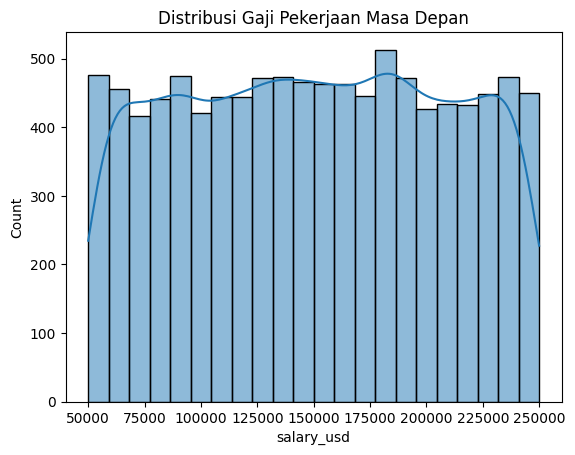

In [ ]:
plt.figure()
sns.histplot(df['salary_usd'], kde=True)
plt.title("Distribusi Gaji Pekerjaan Masa Depan")
plt.show()


# Distribusi :
- Median gaji ≈ USD 150.000

- Gaji maksimum ≈ USD 250.000

- Distribusi gaji cenderung tinggi, menunjukkan fokus pada pekerjaan skill tinggi.


# Insight :

- Dataset merepresentasikan future jobs / high-demand jobs, bukan pekerjaan entry-level.

4.2 Gaji berdasarkan perusahaan

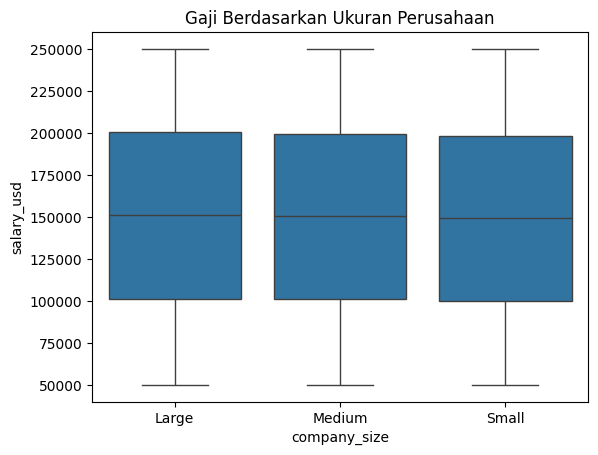

In [ ]:
plt.figure()
sns.boxplot(x='company_size', y='salary_usd', data=df)
plt.title("Gaji Berdasarkan Ukuran Perusahaan")
plt.show()


# Distribusi:

- Small

- Medium

- Large (paling dominan)

# Insight:

- Perusahaan besar lebih aktif membuka lowongan.

- Kita bisa asumsikan perusahaan besar lebih siap menghadapi transformasi digital.

4.3 kerja remote terhadap gaji

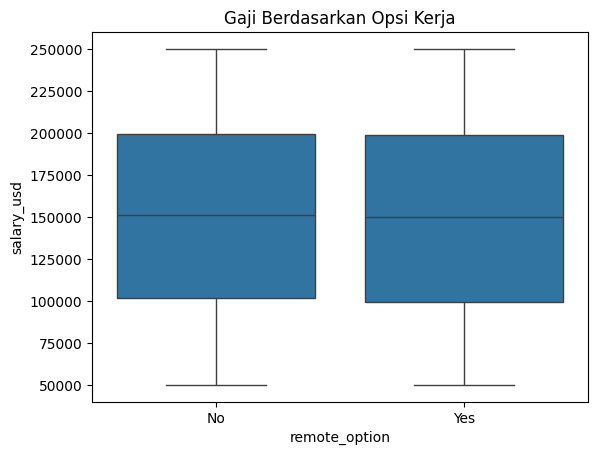

In [ ]:
plt.figure()
sns.boxplot(x='remote_option', y='salary_usd', data=df)
plt.title("Gaji Berdasarkan Opsi Kerja")
plt.show()


# Insight:

- Adanya kategori remote_option disini menunjukkan bahwa :

- Tren kerja remote masih relevan

- Bisa dianalisis pengaruh remote terhadap gaji

4.4 Industry Populer

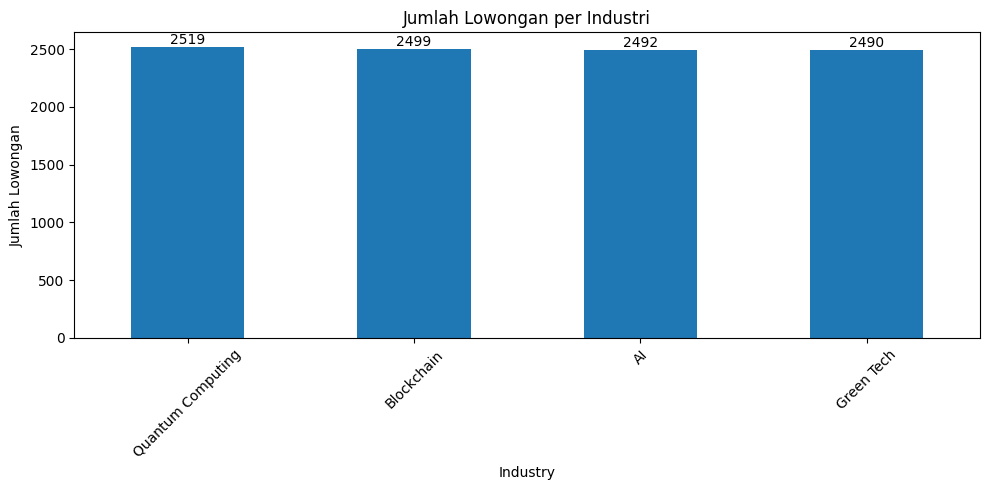

In [ ]:
plt.figure(figsize=(10, 5))

ax = df['industry'].value_counts().plot(kind='bar')

plt.title("Jumlah Lowongan per Industri")
plt.xlabel("Industry")
plt.ylabel("Jumlah Lowongan")

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Insight:

- Dari Dataset ini dapat bahwa dataset ini sangat cocok untuk:

- Analisis industri masa depan

- Identifikasi job title bergaji tinggi

- Potensi besar untuk career recommendation system

# 5.Encoding dan Scalling

In [ ]:
X = df.drop(columns=['salary_usd', 'job_id','posting_date'])
y = df['salary_usd']


In [ ]:
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(exclude=['object']).columns

categorical_features, numerical_features


(Index(['job_title', 'industry', 'location', 'remote_option', 'company_size'], dtype='object'),
 Index(['Climate Data Analysis', 'Energy Modeling', 'Ethereum',
        'Linear Algebra', 'PyTorch', 'Python', 'Qiskit', 'Quantum Algorithms',
        'Rust', 'Solidity', 'TensorFlow'],
       dtype='object'))

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)


# 6.Modelling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


6.1 Linier regression model

In [ ]:
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['job_title', 'industry', 'location', 'remote_option', 'company_size'], dtype='object'))])),
                ('model', LinearRegression())])

In [ ]:
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Nilai MAE dari model Linear regresion : ",mae_lr)
print("Nilai RMSE dari model Linear regresion : ",rmse_lr)
print("Nilai R2 dari model Linear regresion : ",r2_lr)



Nilai MAE dari model Linear regresion :  49745.74311459897
Nilai RMSE dari model Linear regresion :  3309582724.060137
Nilai R2 dari model Linear regresion :  -0.002931493556465714


6.2 Random Forest Regressor

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['job_title', 'industry', 'location', 'remote_option', 'company_size'], dtype='object'))])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [ ]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Nilai MAE dari model Random Forest Regressor : ",mae_rf)
print("Nilai MAE dari model Random Forest Regressor : ",rmse_rf)
print("Nilai MAE dari model Random Forest Regressor : ",r2_rf)


Nilai MAE dari model Random Forest Regressor :  51797.00887462245
Nilai MAE dari model Random Forest Regressor :  3747643223.823078
Nilai MAE dari model Random Forest Regressor :  -0.13568075771637722


6.3 Gradien Boosting Regressor

In [ ]:
gbr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])
gbr_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['job_title', 'industry', 'location', 'remote_option', 'company_size'], dtype='object'))])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [ ]:
y_pred_gbr = gbr_model.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Nilai MAE dari model Gradient Boosting Regressor : ",mae_gbr)
print("Nilai MAE dari model Gradient Boosting Regressor : ",rmse_gbr)
print("Nilai MAE dari model Gradient Boosting Regressor : ",r2_gbr)


Nilai MAE dari model Gradient Boosting Regressor :  49909.0001246989
Nilai MAE dari model Gradient Boosting Regressor :  3338099483.3929744
Nilai MAE dari model Gradient Boosting Regressor :  -0.011573173917301949


# 7.Evaluasi Hasil dan Perbandingan Model

In [ ]:
evaluation = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae_lr, mae_rf, mae_gbr],
    'RMSE': [rmse_lr, rmse_rf, rmse_gbr],
    'R2 Score': [r2_lr, r2_rf, r2_gbr]
})

evaluation


,Model,MAE,RMSE,R2 Score
0,Linear Regression,49745.743115,3.309583e+09,-0.002931
1,Random Forest,51797.008875,3.747643e+09,-0.135681
2,Gradient Boosting,49909.000125,3.338099e+09,-0.011573


# insight yg di dapat dari hasil evaluasi model :
- Linier regression unggul dari keduanya karena nilai mae nya paling kecil , dan rmse nya paling kecil , serta nilai r2 scorenya paling mendekati o-1
- nilai r2 disini minus yang artinya dataset ini fitur yang mendukung untuk gaji ini terlalu sedikit / kurang mendukung , skill required nya disini masih terlalu umum , job titlenya masih terlalu luas sehingga gaji dibuat hampir acak sehingga model tidak menemukan pola yang signifikan.

- yang artinya disini Hubungan antara fitur dan salary_usd lemah , sehingga Model tidak mampu menjelaskan variasi gaji dengan baik

# saran yang dibutuhkan pada dataset ini jika ingin memprediksi gaji dengan :
Menambahkan Fitur Tambahan seperti:

- Level pekerjaan (junior / mid / senior)

- Pengalaman (tahun)

- Pendidikan

- Sertifikasi

- Detail skill (bukan satu kata)


# Kesimpulannya :
Dataset ini lebih sesuai digunakan untuk analisis eksploratif dan pengambilan insight pasar kerja dibandingkan prediksi gaji, karena fitur yang tersedia belum cukup kuat untuk menjelaskan variasi nilai gaji secara signifikan.

- Jangan fokus pada prediksi gaji (regresi)
- Gunakan dataset ini untuk EDA & insight pasar kerja
- Dataset ini lebih cocok Exploratory Data Analysis (EDA)

misalnya :

- Industri apa paling banyak membuka lowongan?

- Skill apa paling sering dibutuhkan?

- Perbedaan gaji antar industri (deskriptif, bukan prediktif)

- Tren remote vs onsite

- Perbandingan rata-rata gaji per industri

- Uji statistik sederhana (mean, median)

- Visualisasi tren